# Multi-bin Fisher forecast for $\Lambda$CDM with AP: joint $P+B$

Joint multi-bin Fisher example using the current `jaxPTPolyPol` power-spectrum and
tree-level bispectrum interfaces with Alcock-Paczynski distortions.

This notebook compares three cases:

- `P + BBN + n_{s,10}`
- `P+B + BBN + n_{s,10}`
- `P+B+BAO + BBN + n_{s,10}`

The bispectrum triangles are built from the same 1-d `k` grid used for the power
spectrum, with the same `dk`, then filtered to keep only canonical triangles with all
sides strictly inside `(k_min, k_max)` and satisfying triangle closure.

The current joint Gaussian covariance includes `C_PP` and `C_BB`. The `C_PB`
cross-covariance hook exists in the library but is still set to zero here.


## Modules


In [1]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol.bao import add_bao_to_fullshape_fisher, bao_fisher_matrix, load_desi_dr2
from jaxptpolypol.covariance import gaussian_covariance_multibin
from jaxptpolypol.inference import (
    fisher_matrix,
    fixed_and_varied_indices,
    gaussian_prior_fisher,
    marginalize_fisher,
)
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs
from jaxptpolypol.priors import build_prior_sigmas_from_spec, load_prior_spec
from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_joint_params,
    pack_pk_params,
    unpack_joint_params,
    unpack_pk_params,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid,
    compute_fiducial_distances,
    make_gaussian_joint_covariance_fn,
    make_joint_pk_bk_fn,
    make_pk_ell_fn,
)

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Computer Modern',
    'font.size': 22,
    'axes.labelsize': 22,
})

## Configuration


In [2]:
bb_power_model = 'kaiser'   # set to '1loop' to reuse the 1-loop P_ell in C_BB
k_bk_min = 0.02
k_bk_max = 0.08
k_nl_rsd = 0.45

n_gl = 16
num_mu = 65
num_phi = 65
background_mode = 'direct'
triangle_preview_rows = 10


## Initialize emulators and theory models


In [3]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
print('Emulator input parameters:', pklin_emulator.parameters)

ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=k_nl_rsd)
print('1-loop Pk terms:', ps1loop_model.pk_terms)
print('BispectrumTreeModel k_nl_rsd:', bispectrum_model.k_nl_rsd)


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator input parameters: ['ombh2' 'omch2' 'logA' 'ns' 'h' 'z' 'A_b' 'eta_b' 'logT_AGN']
1-loop Pk terms: ['22_dd', '13_dd', 'I_d2', 'I_G2', 'I_d2_d2', 'I_G2_G2', 'I_d2_G2', 'F_G2']
BispectrumTreeModel k_nl_rsd: 0.45


## Fiducial cosmology


In [4]:
cosmo_dict = {
            'ombh2': 0.02242,
            'omch2': 0.11933,
            'logA': 3.047,
            'ns': 0.9665,
            'h': 0.6766,
            'z': 0.7,
            'A_b': 3.13,
            'eta_b': 0.603,
            'logT_AGN': 7.8,
        }


cosmo = CosmoParams(cosmo_dict)
print(cosmo)


CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  logA: 3.047
  ns: 0.9665
  h: 0.6766
  z: 0.7
  A_b: 3.13
  eta_b: 0.603
  logT_AGN: 7.8


## Survey bins and nuisance parameters


In [5]:
z_bins   = (0.7, 0.9, 1.1, 1.3, 1.5, 1.8, 2.2)
V_bins   = tuple(v * 1000.0**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
#n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-5, 3.51e-6)
#n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-5, 1e-5)
#n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-5, 5e-5)
n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-5, 1e-4)
n_zbins = len(z_bins)

print(f'Number of redshift bins: {n_zbins}')
for i, (z, V, knl, nd) in enumerate(zip(z_bins, V_bins, knl_bins, n_bins), start=1):
    print(f'  Bin {i}: z={z:.1f}, V={V / 1e9:.2f} (Gpc/h)^3, k_nl={knl:.2f}, ndens={nd:.2e}')


Number of redshift bins: 7
  Bin 1: z=0.7, V=0.59 (Gpc/h)^3, k_nl=0.52, ndens=3.06e-04
  Bin 2: z=0.9, V=0.79 (Gpc/h)^3, k_nl=0.65, ndens=9.61e-04
  Bin 3: z=1.1, V=0.96 (Gpc/h)^3, k_nl=0.82, ndens=9.75e-04
  Bin 4: z=1.3, V=1.09 (Gpc/h)^3, k_nl=1.02, ndens=6.54e-04
  Bin 5: z=1.5, V=1.19 (Gpc/h)^3, k_nl=1.29, ndens=3.40e-04
  Bin 6: z=1.8, V=2.58 (Gpc/h)^3, k_nl=1.82, ndens=2.02e-05
  Bin 7: z=2.2, V=2.71 (Gpc/h)^3, k_nl=2.88, ndens=1.00e-04


In [6]:
def b1z(z):
    return 0.9 + 0.4 * z

def b2z(z):
    return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3

def bG2z(z):
    return -(2.0 / 7.0) * (b1z(z) - 1.0)

def bGamma3z(z):
    return (23.0 / 42.0) * (b1z(z) - 1.0)

def Dplusz(z):
    return float(
        bg.growth_factor(
            cosmo_dict['ombh2'],
            cosmo_dict['omch2'],
            cosmo_dict['h'],
            z,
            mnu=float(cosmo_dict.get('mnu', 0.06)),
        )
    )

def c0z(z):
    return 25.0 * Dplusz(z) ** 2

def c1z(z):
    return 0.0

def c2z(z):
    return 25.0 * Dplusz(z) ** 2

def c4z(z):
    return Dplusz(z) ** 2

def Pshotz(z):
    return 1.0

def Bshotz(z):
    return 1.0

def Ashotz(z):
    return 1.0


In [7]:
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bins), start=1):
    survey = FullShapeSurveyParams(
        shared={
            'bias': {
                'b1': b1z(z),
                'b2': b2z(z),
                'bG2': bG2z(z),
                'bGamma3': bGamma3z(z),
            },
            'stoch': {
                'P_shot': Pshotz(z),
            },
            'k_nl': knl,
            'ndens': nd,
        },
        pk={
            'ctr': {
                'c0': c0z(z),
                'c2': c2z(z),
                'c4': c4z(z),
                'cfog': knl ** (-4),
            },
            'stoch': {
                'a0': 0.0,
                'a2': 0.0,
            },
        },
        bk={
            'ctr': {
                'c1': c1z(z),
            },
            'stoch': {
                'B_shot': Bshotz(z),
                'A_shot': Ashotz(z),
            },
        },
    )
    surveys.append(survey)
    print(f"\n--- Bin {i} (z={z:.1f}) ---")
    print(survey)

pk_survey_keys = surveys[0].pk_param_keys
joint_survey_keys = surveys[0].joint_param_keys



--- Bin 1 (z=0.7) ---
FullShapeSurveyParams(shared={'bias': {'b1': Array(1.18, dtype=float64), 'b2': Array(-0.76257453, dtype=float64), 'bG2': Array(-0.05142857, dtype=float64), 'bGamma3': Array(0.09857143, dtype=float64)}, 'stoch': {'P_shot': Array(1., dtype=float64)}, 'k_nl': Array(0.52, dtype=float64), 'ndens': Array(0.000306, dtype=float64)}, pk={'ctr': {'c0': Array(12.17121827, dtype=float64), 'c2': Array(12.17121827, dtype=float64), 'c4': Array(0.48684873, dtype=float64), 'cfog': Array(13.67686706, dtype=float64)}, 'stoch': {'a0': Array(0., dtype=float64), 'a2': Array(0., dtype=float64)}}, bk={'ctr': {'c1': Array(0., dtype=float64)}, 'stoch': {'B_shot': Array(1., dtype=float64), 'A_shot': Array(1., dtype=float64)}})

--- Bin 2 (z=0.9) ---
FullShapeSurveyParams(shared={'bias': {'b1': Array(1.26, dtype=float64), 'b2': Array(-0.74859059, dtype=float64), 'bG2': Array(-0.07428571, dtype=float64), 'bGamma3': Array(0.14238095, dtype=float64)}, 'stoch': {'P_shot': Array(1., dtype=float6

## Packed parameter vector


In [8]:
packed_params_pk = pack_pk_params(cosmo, surveys)
packed_params_joint = pack_joint_params(cosmo, surveys)
print(f'PK total parameters: {packed_params_pk.shape[0]}')
print(f'Joint total parameters: {packed_params_joint.shape[0]}')
print(f'  Cosmo: {sum(cosmo.param_sizes)}')
print(f'  PK survey per bin: {len(pk_survey_keys)}')
print(f'  Joint survey per bin: {len(joint_survey_keys)}')

unpacked_cosmo_pk, unpacked_surveys_pk = unpack_pk_params(
    packed_params_pk,
    cosmo.param_keys,
    cosmo.param_sizes,
    pk_survey_keys,
    n_zbins,
)
unpacked_cosmo_joint, unpacked_surveys_joint = unpack_joint_params(
    packed_params_joint,
    cosmo.param_keys,
    cosmo.param_sizes,
    joint_survey_keys,
    n_zbins,
)
print(f'\nPK cosmo round-trip: {unpacked_cosmo_pk == cosmo}')
print('PK survey round-trip checks:', [s0 == s1 for s0, s1 in zip(surveys, unpacked_surveys_pk)])
print(f'Joint cosmo round-trip: {unpacked_cosmo_joint == cosmo}')
print('Joint survey round-trip checks:', [s0 == s1 for s0, s1 in zip(surveys, unpacked_surveys_joint)])
print('\nPK survey parameter keys:')
print(pk_survey_keys)
print('\nJoint survey parameter keys:')
print(joint_survey_keys)


PK total parameters: 100
Joint total parameters: 121
  Cosmo: 9
  PK survey per bin: 13
  Joint survey per bin: 16

PK cosmo round-trip: True
PK survey round-trip checks: [False, False, False, False, False, False, False]
Joint cosmo round-trip: True
Joint survey round-trip checks: [Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool)]

PK survey parameter keys:
(('shared', 'bias', 'b1'), ('shared', 'bias', 'b2'), ('shared', 'bias', 'bG2'), ('shared', 'bias', 'bGamma3'), ('shared', 'stoch', 'P_shot'), ('shared', 'k_nl', None), ('shared', 'ndens', None), ('pk', 'ctr', 'c0'), ('pk', 'ctr', 'c2'), ('pk', 'ctr', 'c4'), ('pk', 'ctr', 'cfog'), ('pk', 'stoch', 'a0'), ('pk', 'stoch', 'a2'))

Joint survey parameter keys:
(('shared', 'bias', 'b1'), ('shared', 'bias', 'b2'), ('shared', 'bias', 'bG2'), ('shared', 'bias', 'bGamma3'), ('shared', 'stoch', 'P_shot'), ('shared', 'k_nl

## Fiducial AP distances


In [9]:
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)

for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f'z={z:.1f}: H(z) = {Hz_val:.4f} km/s/Mpc, D_A(z) = {DAz_val:.4f} Mpc')


z=0.7: H(z) = 100.7460 km/s/Mpc, D_A(z) = 1517.2828 Mpc
z=0.9: H(z) = 113.6695 km/s/Mpc, D_A(z) = 1652.5821 Mpc
z=1.1: H(z) = 127.8322 km/s/Mpc, D_A(z) = 1732.1076 Mpc
z=1.3: H(z) = 143.1050 km/s/Mpc, D_A(z) = 1774.2540 Mpc
z=1.5: H(z) = 159.3833 km/s/Mpc, D_A(z) = 1791.1252 Mpc
z=1.8: H(z) = 185.5055 km/s/Mpc, D_A(z) = 1786.0196 Mpc
z=2.2: H(z) = 223.1897 km/s/Mpc, D_A(z) = 1746.9060 Mpc


## Power-spectrum grid and bispectrum triangles


In [10]:
k_pk_min=0.02
k_pk_max=0.20
k = jnp.linspace(k_pk_min, k_pk_max, 37)
dk = float(k[1] - k[0])
n_k = int(k.shape[0])

triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(
    k,
    k_min=k_bk_min,
    k_max=k_bk_max,
    dk=dk,
)
n_tri = int(triangles.shape[0])

print(f'Power-spectrum k grid: n_k = {n_k}, dk = {dk:.5f}')
print(f'Bispectrum triangles in ({k_bk_min:.3f}, {k_bk_max:.3f}): {n_tri}')
print('First few triangles:')
print(np.array(triangles[:triangle_preview_rows]))
print('triangle_dk:', triangle_dk)


Power-spectrum k grid: n_k = 37, dk = 0.00500
Bispectrum triangles in (0.020, 0.080): 264
First few triangles:
[[0.075 0.075 0.075]
 [0.075 0.075 0.07 ]
 [0.075 0.075 0.065]
 [0.075 0.075 0.06 ]
 [0.075 0.075 0.055]
 [0.075 0.075 0.05 ]
 [0.075 0.075 0.045]
 [0.075 0.075 0.04 ]
 [0.075 0.075 0.035]
 [0.075 0.075 0.03 ]]
triangle_dk: 0.005000000000000001


## Differentiable theory wrappers


In [11]:
pk_fn = make_pk_ell_fn(
    ells=(0, 2, 4),
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=n_gl,
    background_mode=background_mode,
)
joint_fn = make_joint_pk_bk_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=n_gl,
    num_mu=num_mu,
    num_phi=num_phi,
    background_mode=background_mode,
)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    bb_power_model=bb_power_model,
    n_gl=n_gl,
    background_mode=background_mode,
)

jitted_pk_fn = jax.jit(pk_fn)
jitted_joint_fn = jax.jit(joint_fn)

print('Joint theory layout:', joint_fn.layout)
print('Joint covariance bb_power_model:', joint_cov_fn.bb_power_model)


Joint theory layout: [bin_0[P0,P2,P4,B0], ..., bin_N[P0,P2,P4,B0]]
Joint covariance bb_power_model: kaiser


## Fiducial theory vectors


In [12]:
pk_fid = jitted_pk_fn(packed_params_pk, k=k)
joint_fid = jitted_joint_fn(packed_params_joint, k=k, triangles=triangles)

print(f'P-only theory vector shape: {pk_fid.shape}')
print(f'Joint P+B theory vector shape: {joint_fid.shape}')
print(f'Per-bin joint block size: {3 * n_k + n_tri}')


P-only theory vector shape: (777,)
Joint P+B theory vector shape: (2625,)
Per-bin joint block size: 375


## Jacobians


In [13]:
jac_pk = jax.jacfwd(jitted_pk_fn, argnums=0)(packed_params_pk, k=k)
jac_pb = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params_joint, k=k, triangles=triangles)

print(f'jac_pk shape: {jac_pk.shape}')
print(f'jac_pb shape: {jac_pb.shape}')


jac_pk shape: (777, 100)
jac_pb shape: (2625, 121)


## Gaussian covariances


In [14]:
pk_all_fid = pk_fid.reshape(n_zbins, 3, n_k)
cov_pk = gaussian_covariance_multibin(V_bins, k, dk, pk_all_fid)
cov_pb = joint_cov_fn(
    packed_params_joint,
    V_survey=V_bins,
    k=k,
    dk=dk,
    triangles=triangles,
    triangle_dk=triangle_dk,
)

print(f'P-only covariance shape: {cov_pk.shape}')
print(f'Joint P+B covariance shape: {cov_pb.shape}')
print('Joint covariance note: C_PB is currently set to zero; only C_PP and C_BB are included.')


P-only covariance shape: (777, 777)
Joint P+B covariance shape: (2625, 2625)
Joint covariance note: C_PB is currently set to zero; only C_PP and C_BB are included.


## BAO Fisher and Gaussian priors


In [15]:
bao_data_dir = '../../ext_data/bao_data/desi_bao_dr2'
bao_dr2 = load_desi_dr2('all', data_dir=bao_data_dir)

n_cosmo_params = sum(cosmo.param_sizes)
fiducial_cosmo = packed_params_pk[:n_cosmo_params]
F_bao = bao_fisher_matrix(
    bao_dr2,
    fiducial_cosmo,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
)

prior_spec = load_prior_spec('eft_eq12_2405_02252')
cosmo_priors = {
    'ombh2': 0.00055,
    'ns': 0.042,
}
prior_sigmas_pk = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=n_zbins,
    observable='pk',
    spec=prior_spec,
    cosmo_priors=cosmo_priors,
)
prior_sigmas_joint = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    n_bins=n_zbins,
    observable='joint',
    spec=prior_spec,
    cosmo_priors=cosmo_priors,
)
F_prior_pk = gaussian_prior_fisher(packed_params_pk.shape[0], prior_sigmas_pk)
F_prior_joint = gaussian_prior_fisher(packed_params_joint.shape[0], prior_sigmas_joint)

F_pk_raw = fisher_matrix(cov_pk, jac_pk)
F_pb_raw = fisher_matrix(cov_pb, jac_pb)
F_pb_bao_raw = add_bao_to_fullshape_fisher(F_pb_raw, F_bao, n_cosmo=n_cosmo_params)

F_p = F_pk_raw + F_prior_pk
F_pb = F_pb_raw + F_prior_joint
F_pb_bao = F_pb_bao_raw + F_prior_joint

print(f'DESI DR2 BAO data points: {len(bao_dr2.data_points)}')
print(f'F_bao shape: {F_bao.shape}')
print(f'F_p shape: {F_p.shape}')
print(f'F_pb shape: {F_pb.shape}')
print(f'F_pb_bao shape: {F_pb_bao.shape}')
print('Applied Gaussian priors: ombh2 = 0.00055, ns = 0.042 (BBN + n_{s,10}), plus Eq. (12) EFT/stochastic priors from arXiv:2405.02252')


DESI DR2 BAO data points: 13
F_bao shape: (9, 9)
F_p shape: (100, 100)
F_pb shape: (121, 121)
F_pb_bao shape: (121, 121)
Applied Gaussian priors: ombh2 = 0.00055, ns = 0.042 (BBN + n_{s,10}), plus Eq. (12) EFT/stochastic priors from arXiv:2405.02252


## Marginalization setup


In [16]:
n_survey_params_pk = len(pk_survey_keys)
n_survey_params_joint = len(joint_survey_keys)

fixed_cosmo_names = {'z', 'A_b', 'eta_b', 'logT_AGN'}
fixed_cosmo_idx = [i for i, name in enumerate(cosmo.param_keys) if name in fixed_cosmo_names]

fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets_pk = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]
fixed_survey_offsets_joint = [i for i, key in enumerate(joint_survey_keys) if key in fixed_survey_keys]

fixed_idx_pk, varied_idx_pk = fixed_and_varied_indices(
    n_cosmo_params,
    n_survey_params_pk,
    n_zbins,
    fixed_cosmo_idx,
    fixed_survey_offsets_pk,
)
fixed_idx_joint, varied_idx_joint = fixed_and_varied_indices(
    n_cosmo_params,
    n_survey_params_joint,
    n_zbins,
    fixed_cosmo_idx,
    fixed_survey_offsets_joint,
)

packed_varied_pk = packed_params_pk[np.array(varied_idx_pk)]
packed_varied_joint = packed_params_joint[np.array(varied_idx_joint)]
F_marg_p = marginalize_fisher(F_p, varied_idx_pk)
F_marg_pb = marginalize_fisher(F_pb, varied_idx_joint)
F_marg_pb_bao = marginalize_fisher(F_pb_bao, varied_idx_joint)

print(f'PK total parameters: {packed_params_pk.shape[0]}')
print(f'Joint total parameters: {packed_params_joint.shape[0]}')
print(f'Fixed cosmological indices: {fixed_cosmo_idx}')
print(f'Fixed PK survey offsets: {fixed_survey_offsets_pk}')
print(f'Fixed joint survey offsets: {fixed_survey_offsets_joint}')
print(f'Varied PK parameters: {len(varied_idx_pk)}')
print(f'Varied joint parameters: {len(varied_idx_joint)}')


PK total parameters: 100
Joint total parameters: 121
Fixed cosmological indices: [5, 6, 7, 8]
Fixed PK survey offsets: [5, 6]
Fixed joint survey offsets: [5, 6]
Varied PK parameters: 82
Varied joint parameters: 103


In [17]:
from jaxptpolypol.chain_analysis import DEFAULT_LATEX_LABELS, make_fullshape_spec
from jaxptpolypol.inference import fisher_diagnostics, format_fisher_diagnostics

spec_pk = make_fullshape_spec(
  cosmo_keys=cosmo.param_keys,
  cosmo_sizes=cosmo.param_sizes,
  survey_keys=pk_survey_keys,
  n_bins=len(z_bins),
  varied_idx=varied_idx_pk,
  analysis_kind="pk",
)
spec_joint = make_fullshape_spec(
  cosmo_keys=cosmo.param_keys,
  cosmo_sizes=cosmo.param_sizes,
  survey_keys=joint_survey_keys,
  n_bins=len(z_bins),
  varied_idx=varied_idx_joint,
  analysis_kind="pb",
)

varied_names_pk = list(spec_pk.varied_param_names())
varied_names_joint = list(spec_joint.varied_param_names())
cosmo_varied_global_idx = [i for i in range(n_cosmo_params) if i not in fixed_cosmo_idx]
cosmo_marg_idx_pk = np.array([varied_idx_pk.index(i) for i in cosmo_varied_global_idx])
cosmo_marg_idx_joint = np.array([varied_idx_joint.index(i) for i in cosmo_varied_global_idx])

print(varied_names_pk[:10])
print(varied_names_joint[:10])


['ombh2', 'omch2', 'logA', 'ns', 'h', 'bias.b1@bin0', 'bias.b2@bin0', 'bias.bG2@bin0', 'bias.bGamma3@bin0', 'stoch.P_shot@bin0']
['ombh2', 'omch2', 'logA', 'ns', 'h', 'bias.b1@bin0', 'bias.b2@bin0', 'bias.bG2@bin0', 'bias.bGamma3@bin0', 'stoch.P_shot@bin0']


In [18]:
fisher_cases = [
    {
        'label': r'$P$ + BBN + $n_{s,10}$',
        'fisher': F_marg_p,
        'varied_names': varied_names_pk,
        'packed_varied': packed_varied_pk,
        'cosmo_marg_idx': cosmo_marg_idx_pk,
        'color': 'royalblue',
        'ls': '-',
    },
    {
        'label': r'$P+B$ + BBN + $n_{s,10}$',
        'fisher': F_marg_pb,
        'varied_names': varied_names_joint,
        'packed_varied': packed_varied_joint,
        'cosmo_marg_idx': cosmo_marg_idx_joint,
        'color': 'crimson',
        'ls': '--',
    },
    {
        'label': r'$P+B+$ DESI DR2 BAO + BBN + $n_{s,10}$',
        'fisher': F_marg_pb_bao,
        'varied_names': varied_names_joint,
        'packed_varied': packed_varied_joint,
        'cosmo_marg_idx': cosmo_marg_idx_joint,
        'color': 'darkorange',
        'ls': '-.',
    },
]

for case in fisher_cases:
  diag = fisher_diagnostics(
      case['fisher'],
      param_names=case['varied_names'],
      max_modes=4,
      max_params_per_mode=6,
  )
  print(f"\n{case['label']}")
  print(format_fisher_diagnostics(diag, max_modes=4, max_params_per_mode=6))



$P$ + BBN + $n_{s,10}$
rank=79/82, weak_modes=3, cond=inf, sym_err=2.025e-16, weak_tol=4.134e-03
smallest eigenvalues: 4.319e-05, 1.434e-04, 3.586e-03, 1.280e-02
null-space participation: bias.bGamma3@bin4 (0.71), bias.bGamma3@bin5 (0.71), bias.bGamma3@bin6 (0.69), bias.b2@bin6 (0.21), bias.b2@bin5 (0.20), bias.b2@bin4 (0.19)
mode 0 [weak] eig=4.319e-05: bias.bGamma3@bin5 (+0.841), bias.b2@bin5 (-0.444), bias.bG2@bin5 (-0.308), bias.bGamma3@bin6 (+0.010), bias.b2@bin6 (-0.006), bias.bG2@bin6 (-0.004)
mode 1 [weak] eig=1.434e-04: bias.bGamma3@bin6 (+0.832), bias.b2@bin6 (-0.461), bias.bG2@bin6 (-0.309), bias.bGamma3@bin5 (-0.011), bias.bGamma3@bin4 (+0.008), bias.b2@bin4 (-0.005)
mode 2 [weak] eig=3.586e-03: bias.bGamma3@bin4 (+0.845), bias.b2@bin4 (-0.432), bias.bG2@bin4 (-0.308), bias.bGamma3@bin3 (+0.034), stoch.P_shot@bin4 (+0.023), bias.b2@bin3 (-0.023)
mode 3 [smallest] eig=1.280e-02: bias.bGamma3@bin3 (-0.777), bias.b2@bin3 (+0.392), bias.b2@bin5 (+0.324), bias.bG2@bin3 (+0.284)

In [19]:
cosmo_varied_names_pk = [varied_names_pk[i] for i in cosmo_marg_idx_pk]
cosmo_varied_names_joint = [varied_names_joint[i] for i in cosmo_marg_idx_joint]
native_cosmo_keys = tuple(cosmo.param_keys[i] for i in cosmo_varied_global_idx)
cosmo_param_names = tuple(DEFAULT_LATEX_LABELS.get(name, name) for name in native_cosmo_keys)

print(cosmo_varied_names_pk)
print(cosmo_varied_names_joint)
print(native_cosmo_keys)


['ombh2', 'omch2', 'logA', 'ns', 'h']
['ombh2', 'omch2', 'logA', 'ns', 'h']
('ombh2', 'omch2', 'logA', 'ns', 'h')


## Forecast comparison


/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_20180/4035422553.py:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


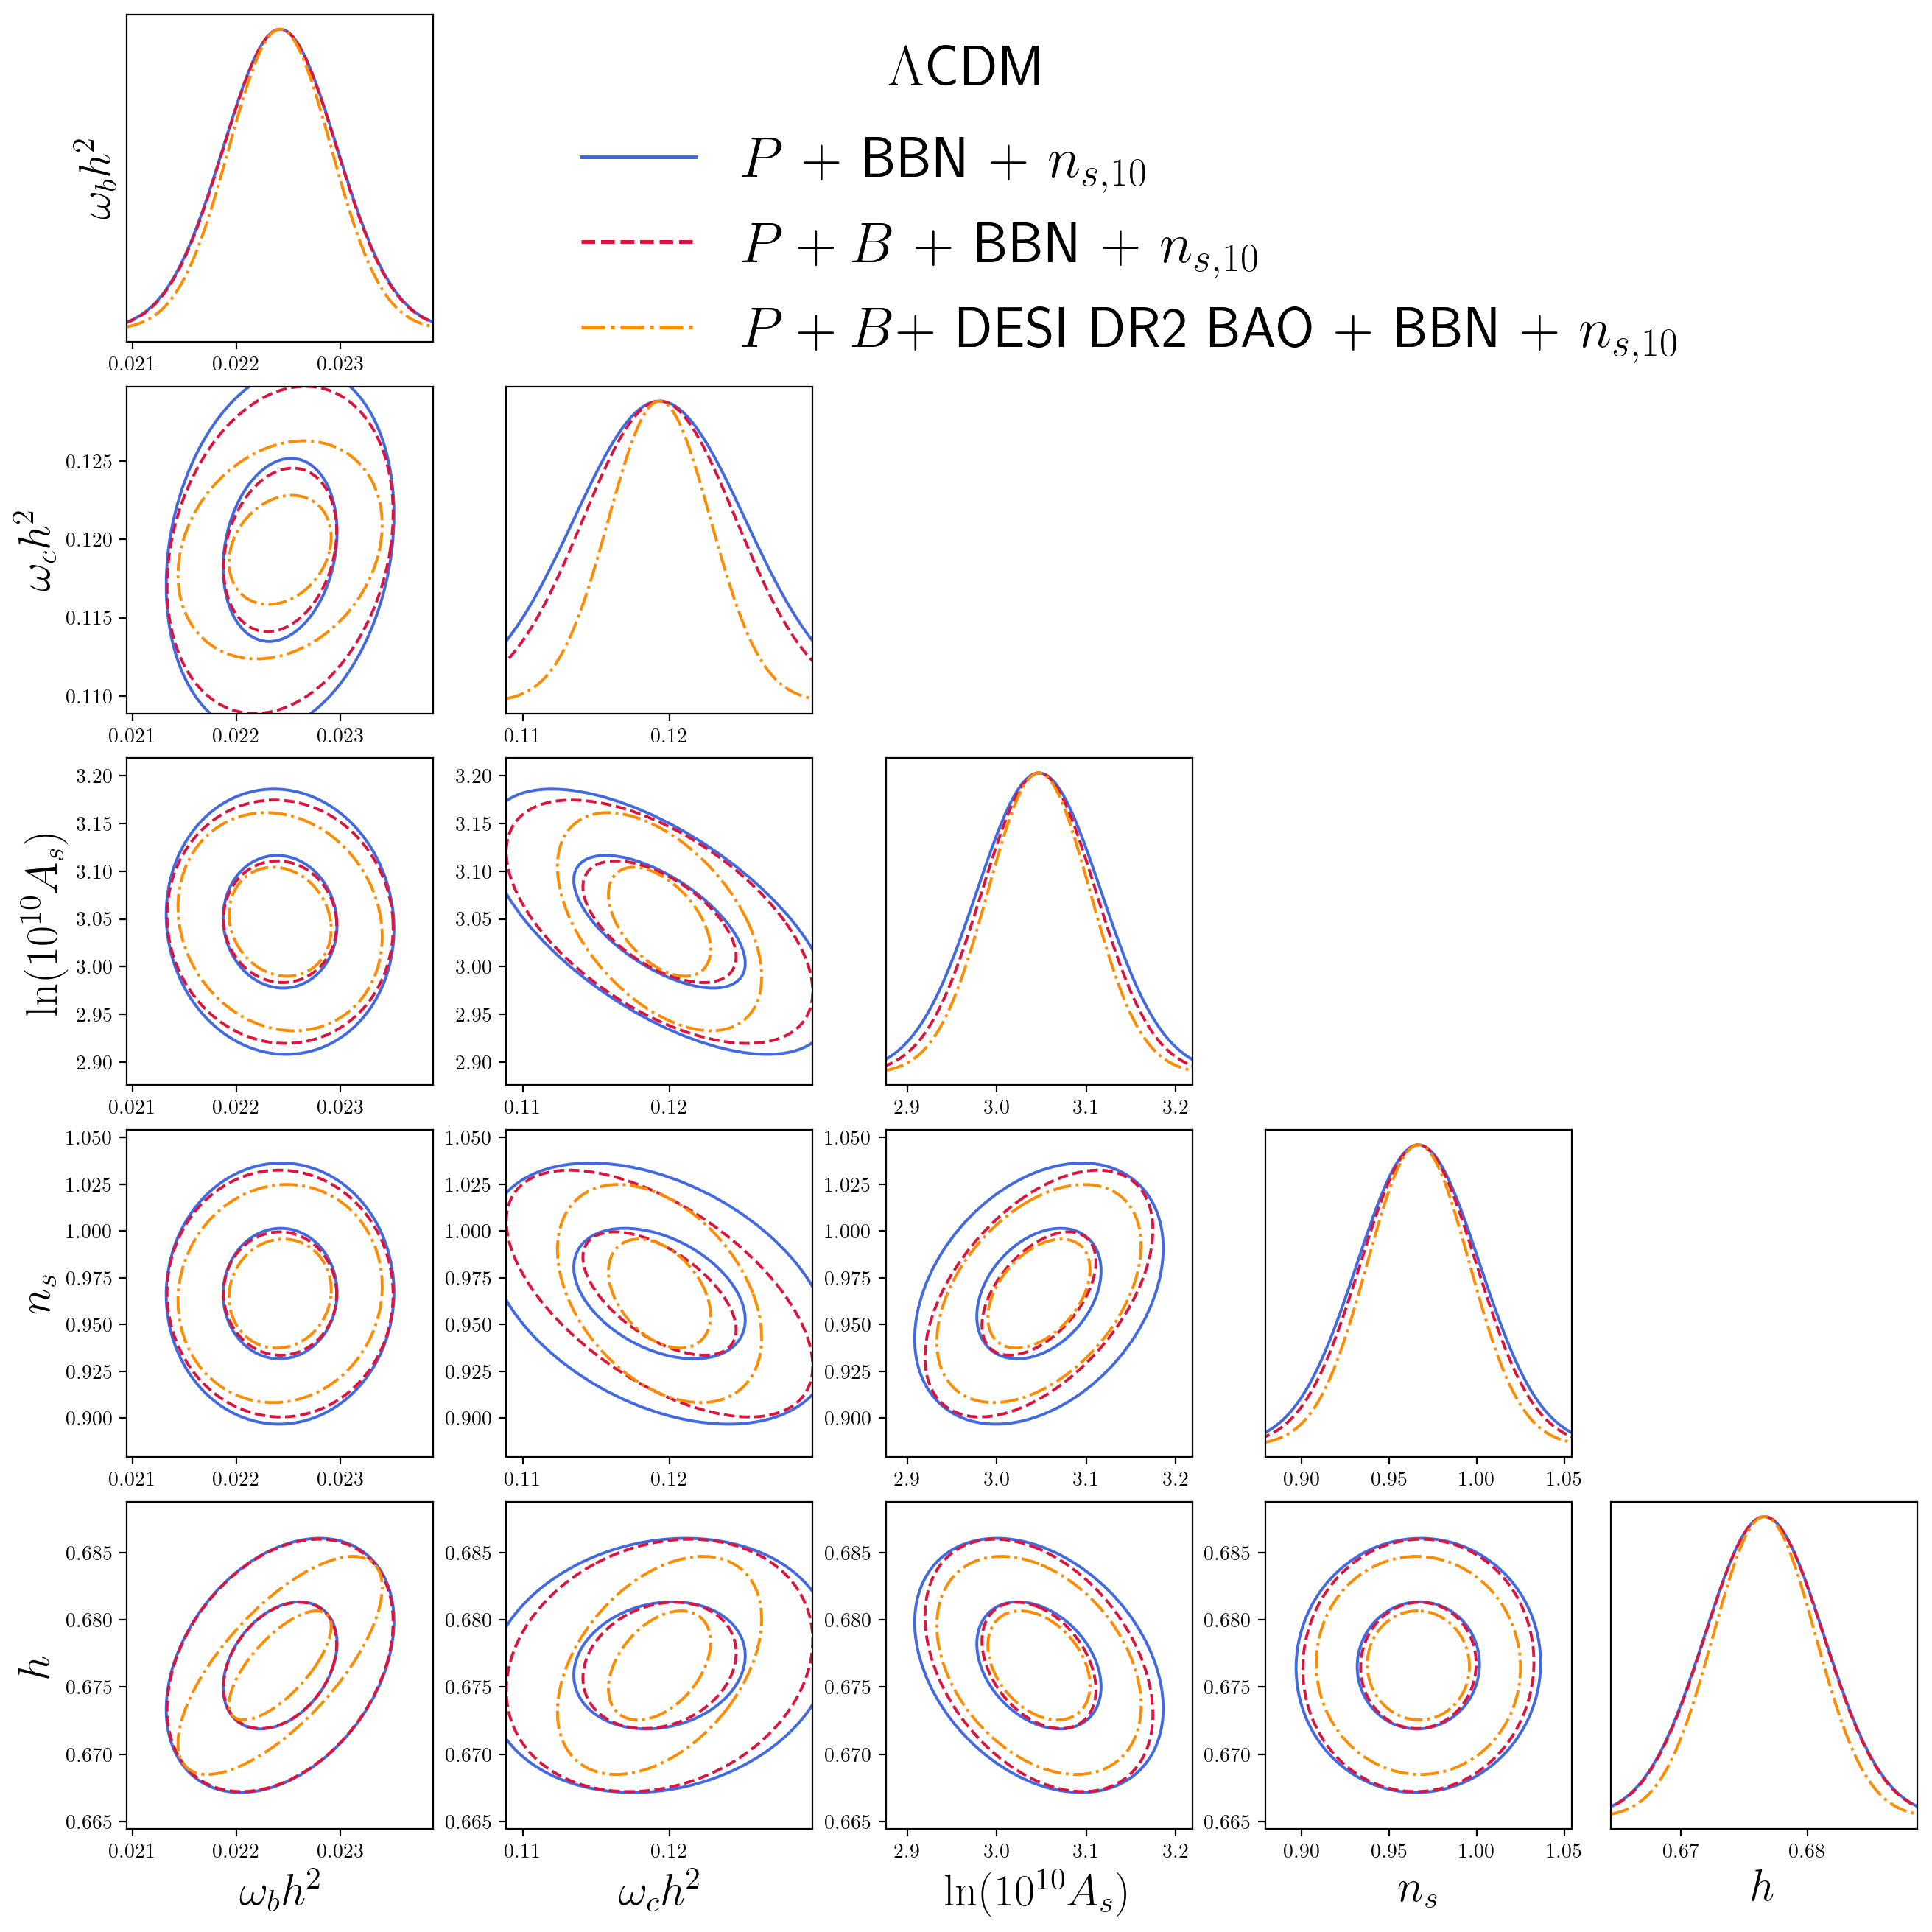

In [20]:
plt.rcParams.update({'font.size': 10})
n_cosmo_plot = len(cosmo_param_names)
fig = plt.figure(figsize=(n_cosmo_plot * 2.6, n_cosmo_plot * 2.6), constrained_layout=True)
legend_handles = [
    mlines.Line2D([], [], color=case['color'], ls=case['ls'], lw=1.8, label=case['label'])
    for case in fisher_cases
]

for i in range(n_cosmo_plot):
    for j in range(n_cosmo_plot):
        ax = plt.subplot(n_cosmo_plot, n_cosmo_plot, i * n_cosmo_plot + j + 1)
        if j < i:
            for case in fisher_cases:
                plot_contours(
                    case['fisher'],
                    case['packed_varied'],
                    np.array([case['cosmo_marg_idx'][j], case['cosmo_marg_idx'][i]]),
                    ax=ax,
                    fill=False,
                    color=case['color'],
                    ls=case['ls'],
                    lw=1.4,
                )
        elif j == i:
            for case in fisher_cases:
                plot_Gaussian(
                    case['fisher'],
                    case['packed_varied'],
                    case['cosmo_marg_idx'][i],
                    ax=ax,
                    color=case['color'],
                    ls=case['ls'],
                    lw=1.4,
                )
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == n_cosmo_plot - 1:
            plt.xlabel(cosmo_param_names[j])
        if j == 0:
            plt.ylabel(cosmo_param_names[i])

fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.90, 0.96), frameon=False, fontsize=28)
fig.suptitle(r'$\Lambda$CDM', fontsize=28, y=0.98)
fig.subplots_adjust(top=0.88)


## Marginalized 1$\sigma$ constraints


In [21]:
def marginalized_sigmas_from_fisher(fisher):
    cov = np.linalg.pinv(np.asarray(fisher, dtype=float), hermitian=True)
    return np.sqrt(np.clip(np.diag(cov), 0.0, None))

sigma_p = marginalized_sigmas_from_fisher(F_marg_p)
sigma_pb = marginalized_sigmas_from_fisher(F_marg_pb)
sigma_pb_bao = marginalized_sigmas_from_fisher(F_marg_pb_bao)

print('Marginalized 1-sigma constraints for varied cosmological parameters')
print('=' * 110)
print(f"{'Parameter':>18s}  {'Fiducial':>12s}  {'P + BBN+ns10':>16s}  {'P+B + BBN+ns10':>18s}  {'P+B+BAO + BBN+ns10':>22s}")
print('-' * 110)

for i, name in enumerate(cosmo_param_names):
    fid = float(packed_varied_pk[cosmo_marg_idx_pk[i]])
    s_p = float(sigma_p[cosmo_marg_idx_pk[i]])
    s_pb = float(sigma_pb[cosmo_marg_idx_joint[i]])
    s_pb_bao = float(sigma_pb_bao[cosmo_marg_idx_joint[i]])
    print(f"{name:>18s}  {fid:12.5g}  {s_p:16.5g}  {s_pb:18.5g}  {s_pb_bao:22.5g}")


Marginalized 1-sigma constraints for varied cosmological parameters
         Parameter      Fiducial      P + BBN+ns10      P+B + BBN+ns10      P+B+BAO + BBN+ns10
--------------------------------------------------------------------------------------------------------------
    $\omega_b h^2$       0.02242         0.0005471           0.0005431              0.00049067
    $\omega_c h^2$       0.11933         0.0058528           0.0052291               0.0034858
$\ln(10^{10} A_s)$         3.047          0.069439            0.063682                0.057076
             $n_s$        0.9665          0.034882             0.03297                 0.02914
               $h$        0.6766         0.0047234           0.0046909               0.0040529


## Selected unmarginalized parameters

In [22]:
# Edit this list to choose the final unmarginalized parameters shown below.
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
)

selected_fisher_cases = []
for case in fisher_cases:
    projection = project_case_to_specs(
        case['fisher'],
        case['packed_varied'],
        case['cosmo_marg_idx'],
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({**case, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print(selected_param_names)
print(selected_param_labels)
print(selected_fisher_cases[0]['projection'].fid_plot)


('Omega_m', 'H0', 'sigma8')
('$\\Omega_m$', '$H_0$', '$\\sigma_8$')
[ 0.31104863 67.66        0.81038407]


## Reprojected corner plot

/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_20180/385765617.py:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


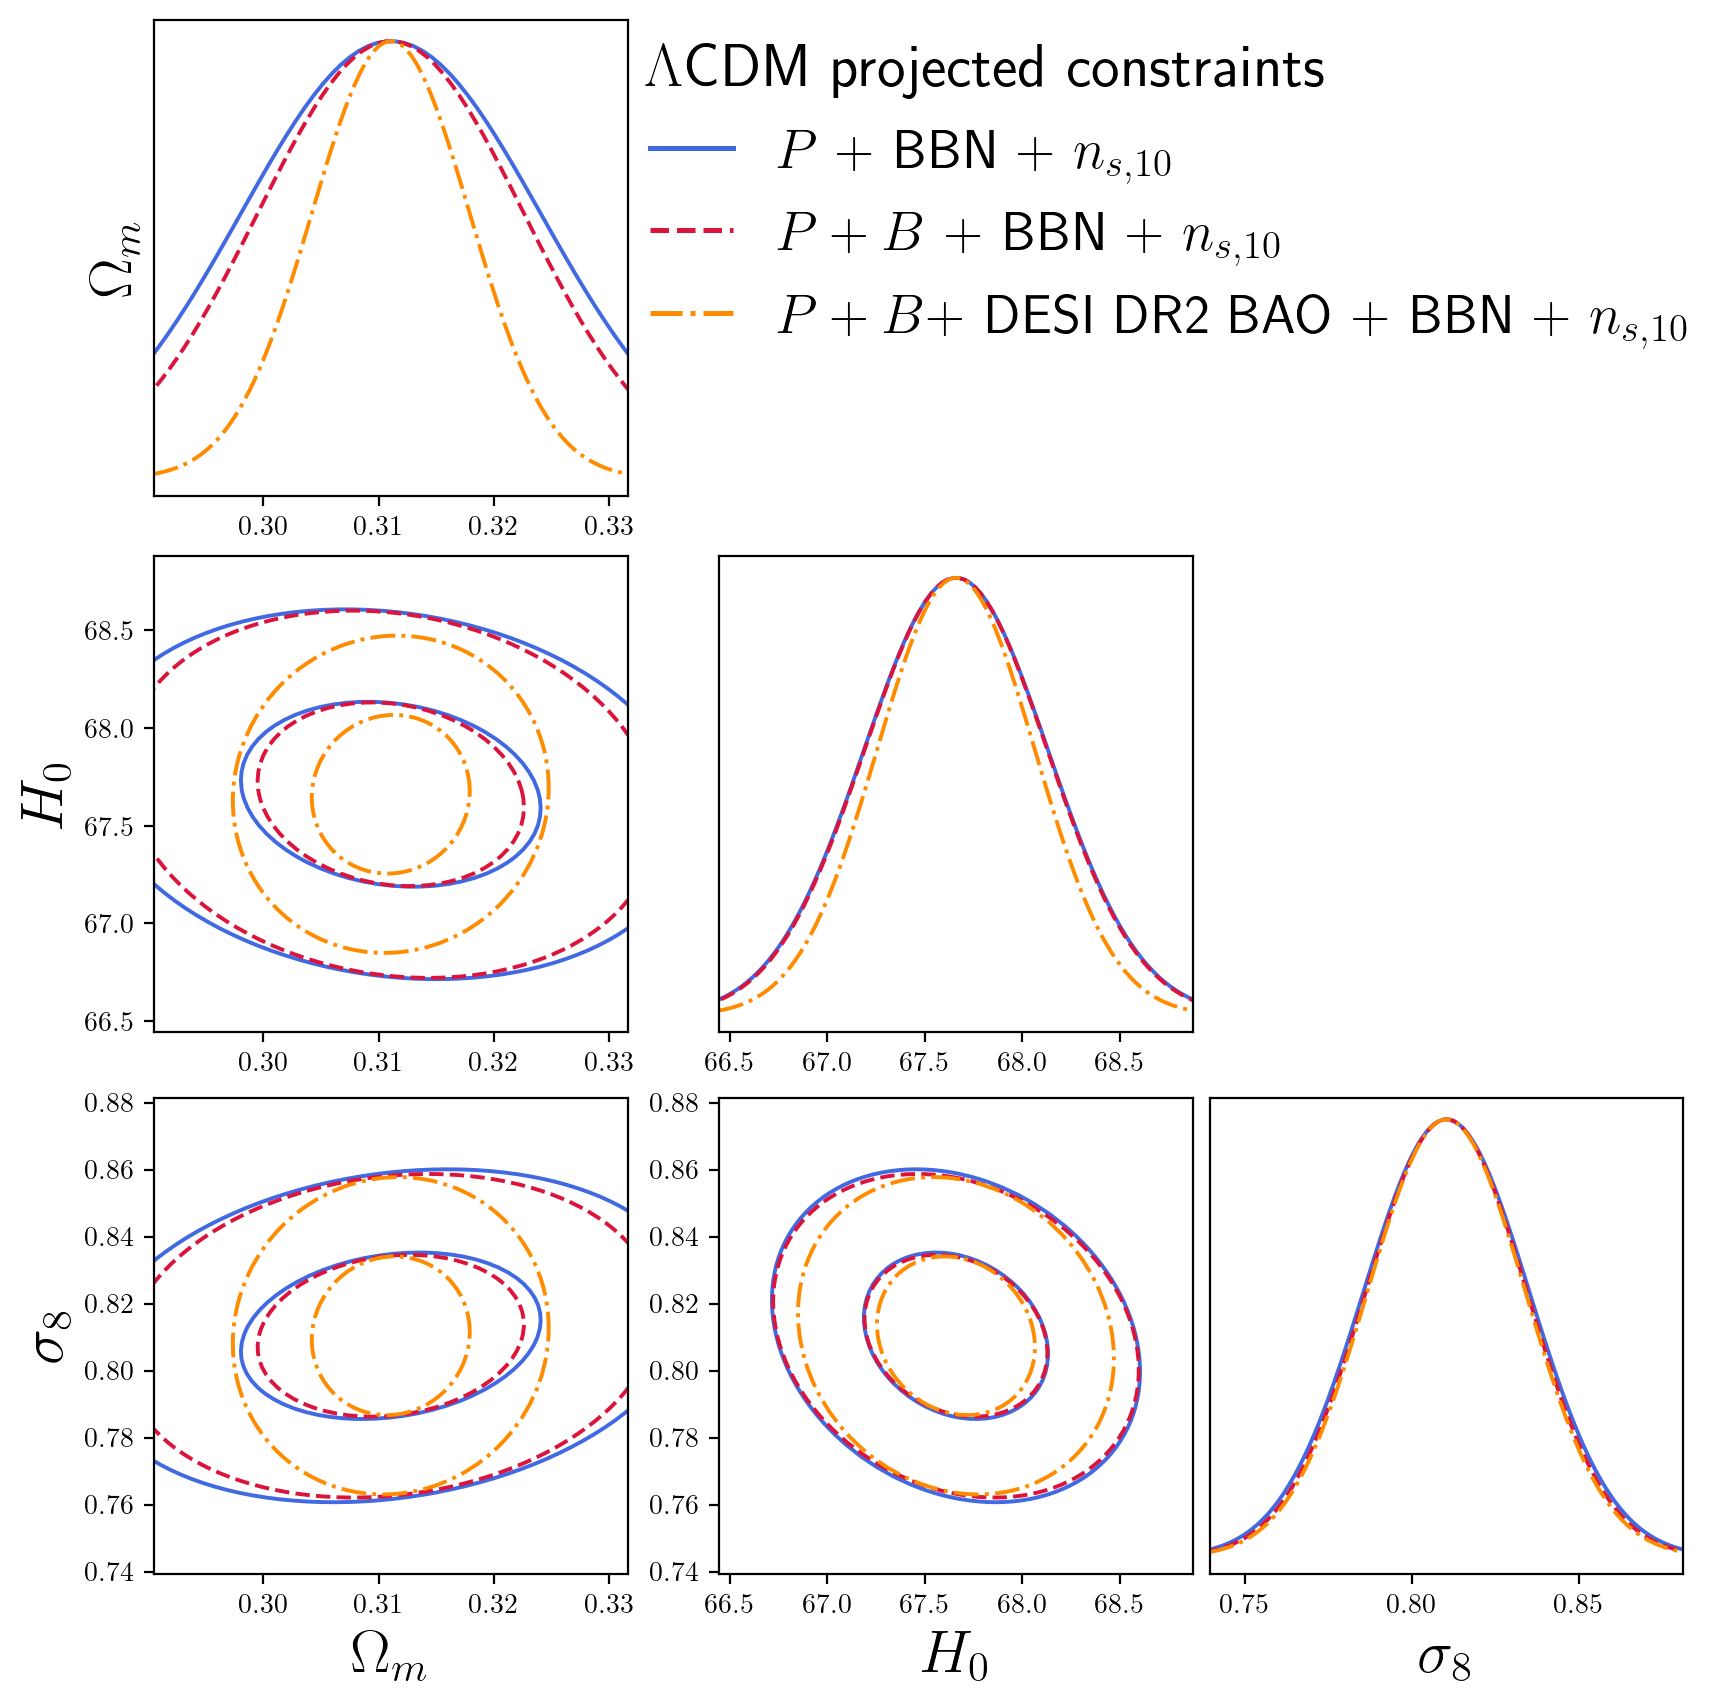

In [23]:
plt.rcParams.update({'font.size': 10})
n_selected_plot = len(selected_param_labels)
fig = plt.figure(figsize=(n_selected_plot * 2.8, n_selected_plot * 2.8), constrained_layout=True)
legend_handles = [
    mlines.Line2D([], [], color=case['color'], ls=case['ls'], lw=1.8, label=case['label'])
    for case in selected_fisher_cases
]

for i in range(n_selected_plot):
    for j in range(n_selected_plot):
        ax = plt.subplot(n_selected_plot, n_selected_plot, i * n_selected_plot + j + 1)
        if j < i:
            for case in selected_fisher_cases:
                plot_contours(
                    case['projection'].fisher_plot,
                    case['projection'].fid_plot,
                    np.array([j, i]),
                    ax=ax,
                    fill=False,
                    color=case['color'],
                    ls=case['ls'],
                    lw=1.4,
                )
        elif j == i:
            for case in selected_fisher_cases:
                plot_Gaussian(
                    case['projection'].fisher_plot,
                    case['projection'].fid_plot,
                    i,
                    ax=ax,
                    color=case['color'],
                    ls=case['ls'],
                    lw=1.4,
                )
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == n_selected_plot - 1:
            plt.xlabel(selected_param_labels[j])
        if j == 0:
            plt.ylabel(selected_param_labels[i])

fig.legend(handles=legend_handles, handlelength=1.5, loc='upper left', bbox_to_anchor=(0.35, 0.96), frameon=False, fontsize=20)
fig.suptitle(r'$\Lambda$CDM projected constraints', fontsize=22, x=0.58, y=0.98)
fig.subplots_adjust(top=0.88)


## Reprojected 1$\sigma$ constraints

In [24]:
print('Marginalized 1-sigma constraints for selected unmarginalized parameters')
print('=' * 110)
print(f"{'Parameter':>18s}  {'Fiducial':>12s}  {'P + BBN+ns10':>16s}  {'P+B + BBN+ns10':>18s}  {'P+B+BAO + BBN+ns10':>22s}")
print('-' * 110)

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(marginalized_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    print(f"{name:>18s}  {fid:12.5g}  {sigma_vals[0]:16.5g}  {sigma_vals[1]:18.5g}  {sigma_vals[2]:22.5g}")


Marginalized 1-sigma constraints for selected unmarginalized parameters
         Parameter      Fiducial      P + BBN+ns10      P+B + BBN+ns10      P+B+BAO + BBN+ns10
--------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105          0.013002            0.011553               0.0068531
             $H_0$         67.66           0.47234             0.46909                 0.40529
        $\sigma_8$       0.81038          0.024842            0.024143                0.023677
